In [28]:
import sys
import os
import pandas as pd
import numpy as np
from pycox.models.cox import CoxPH
from pycox.evaluation import EvalSurv
import matplotlib.pyplot as plt
import torchtuples as tt
import shap
import scipy.integrate
scipy.integrate.simps = scipy.integrate.simpson



from itertools import product
import torch

sys.path.append(os.path.abspath("../../"))
from src.dataset.generate_dataset import TorchPreprocessing
from src.utils.kapplan_meir import k_m_cox
from src.dataset.DataSet import SurvivalDataSet
from src.utils.Preprocessing import Preprocessor
from src.utils.ConvertTextToCsv import TextToCsv
from src.utils.set_seed import set_seed
from src.utils.cox_models import *



import numpy as np
import torch


%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
set_seed(42)

In [3]:
pp = Preprocessor()

#### Preprocessing of the Data

In [4]:
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_data = pp.clean_columns_dataset(df_clinical_data)
list_df = pp.total_type_len_type_cancer(df_clinical_data)
df_clinical_data["Tumor-Cancer"] = list_df
df_clinical_data["Tumor-Cancer"].unique()

df_mRNA_raw_data = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")


Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 299 - Total(%) 0.37
Shape of the CSV: (20440, 819)


In [5]:
df_merged = TorchPreprocessing(df_mRNA_raw_data,df_clinical_data, 23360).get_comparation_df()
 
comparation_df = df_merged.loc[
    df_merged["Tumor-Cancer"].isin(["Luminal A", "Luminal B", "TNBC", "HER2-enriched"]),
]

comparation_df["Tumor-Cancer"].unique()

print(f"Samples: {comparation_df.shape[0]}, Genes: {comparation_df.shape[1]}")

Genes before Treshold: 20434
count    20434.000000
mean        73.977831
std        155.539160
min          0.000000
25%          0.000000
50%          0.000000
75%         21.000000
max        519.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 18533
Samples: 519, Genes: 18534


In [6]:
zero_reduced_df =  comparation_df.drop(["Sample ID"], axis=1)
results_df, desing, expr = pp.initialize_limma(zero_reduced_df, column="Tumor-Cancer", column_event="Overall Survival (Months)", column_status="Overall Survival Status")

In [7]:
results_df

,HER2-enriched,Luminal A,Luminal B,AveExpr,F,pvalue,adj_pvalue
CLPTM1L,11.102512,11.135727,11.432034,11.178603,3411.584991,0.000000e+00,0.000000e+00
CENPI,5.470060,5.888030,6.715312,5.789382,1450.712650,0.000000e+00,0.000000e+00
MYO7A,6.271601,6.449378,6.908579,6.404052,1924.652991,0.000000e+00,0.000000e+00
TICAM1,9.053592,8.909586,9.122539,9.029430,3672.081507,0.000000e+00,0.000000e+00
ATRN,11.000081,10.966267,10.703819,10.940783,3599.868581,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...
SLC28A2,0.277010,0.242954,0.086340,0.243943,14.846553,1.159021e-09,1.159271e-09
SSX6,0.132164,0.226988,0.328592,0.195638,14.669272,1.503423e-09,1.503666e-09
TMEM229A,0.207897,0.218256,0.103054,0.198622,14.233538,2.848866e-09,2.849174e-09
GADL1,0.142536,0.159804,0.223690,0.175297,13.301483,1.116376e-08,1.116436e-08


In [8]:
N_GENES = 1000
top_genes_limma = results_df.sort_values("pvalue").index[:N_GENES].tolist()

In [9]:
torch_preprocessing = TorchPreprocessing(df_mRNA_raw_data, df_clinical_data, 23360)
torch_preprocessing.genes_expression = top_genes_limma
genes_expression = top_genes_limma
X_scaled, durations, events, scaler, sample_ids = torch_preprocessing.get_data_set(60, return_ids=True)


Genes before Treshold: 1003
count    1003.000000
mean        0.929212
std         3.489359
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        42.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 1003


In [10]:
X_scaled.shape

(519, 1000)

In [11]:
surival_data_set  = SurvivalDataSet(X_scaled, durations, events)

In [12]:
import json
from src.dataset.split_data import split_dataset_by_ids

# Load the canonical split created by limma.ipynb so the NN uses the SAME patients.
split = json.load(open("splits.json"))
set_seed(42)
(train_X, train_durations, train_events), \
(val_X, val_durations, val_events), \
(test_X, test_durations, test_events) = split_dataset_by_ids(
    surival_data_set, sample_ids,
    split["train_ids"], split["val_ids"], split["test_ids"]
)
print(f"Train: {train_X.shape[0]}, Val: {val_X.shape[0]}, Test: {test_X.shape[0]}")

Train: 331, Val: 84, Test: 104


In [13]:
train_X.shape

torch.Size([331, 1000])

### Grid Search Hyperparameters for the DeepSurv(Pycox CoxPH)

In [14]:
from itertools import product

in_features = train_X.shape[1]
output_bias = False
param_grid = {
    "num_nodes": [
        [16], [32], [64], [128], [256],
        [16, 16], [32, 16], [32, 32], [64, 32],
    ],
    "dropout": [0.2,0.3, 0.4],
    "batch_norm": [True, False],
    "lr": [1e-3, 5e-4, 1e-4, 1e-5],
    "weight_decay": [0, 1e-4, 1e-3],
    "batch_size": [128, 256, 512],
}
grid = list(product(
    param_grid["num_nodes"],
    param_grid["dropout"],
    param_grid["batch_norm"],
    param_grid["lr"],
    param_grid["weight_decay"],
    param_grid["batch_size"],
))

### Grid Search for the DeepSurv(Pycox CoxPH)

In [15]:
from pycox.evaluation import EvalSurv

best_score = -1
best_params = None
grid_results = []

val_X = np.array(val_X)
val_durations = np.array(val_durations)
val_events = np.array(val_events).astype(bool)

for num_nodes, dp, bn, lr, wd, batch_size in grid:
    try:
        set_seed(42)
        net = tt.torchtuples.practical.MLPVanilla(
            in_features=in_features,
            num_nodes=num_nodes,
            out_features=1,
            dropout=dp,
            output_bias=False,
            batch_norm=bn,
        )
        model_gs = CoxPH(net, tt.torchtuples.optim.Adam(lr=lr, weight_decay=wd))
        
        callbacks = [tt.torchtuples.callbacks.EarlyStopping(patience=40)]
        model_gs.fit(
            input=train_X,
            target=(train_durations, train_events),
            batch_size=batch_size,
            epochs=150,
            callbacks=callbacks,
            verbose=False,
            val_data=(val_X, (val_durations, val_events)),
            val_batch_size=batch_size
        )
        
        
        model_gs.compute_baseline_hazards()
        surv_val = model_gs.predict_surv_df(val_X)
        ev = EvalSurv(surv_val, val_durations, val_events, censor_surv='km')
        c_index = ev.concordance_td()

        grid_results.append({
            'num_nodes': num_nodes, 'dropout': dp, 'batch_norm': bn,
            'lr': lr, 'weight_decay': wd, 'batch_size': batch_size,
            'c_index': c_index
        })

        if c_index > best_score:
            best_score = c_index
            best_params = {
                'num_nodes': num_nodes, 'dropout': dp, 'batch_norm': bn,
                'lr': lr, 'weight_decay': wd, 'batch_size': batch_size
            }
    except Exception as e:
        continue

print(f"Mejor C-index en validación: {best_score:.4f}")
print(f"Mejores parámetros: {best_params}")

Mejor C-index en validación: 0.7816
Mejores parámetros: {'num_nodes': [32, 16], 'dropout': 0.2, 'batch_norm': True, 'lr': 0.001, 'weight_decay': 0.001, 'batch_size': 128}


#### Training of the DeepSurv

In [17]:
in_features = train_X.shape[1]
output_bias = False
out_features = 1
"""num_nodes = best_params['num_nodes']
dropout = best_params['dropout']
batch_norm = best_params['batch_norm']
lr = best_params['lr']
weight_decay = best_params['weight_decay']
batch_size = best_params['batch_size']
"""

num_nodes = [32, 16]
dropout = 0.2
batch_norm = True
lr = 0.001
weight_decay = 0.001
batch_size = 128

set_seed(42)
net = tt.torchtuples.practical.MLPVanilla(
    in_features=in_features, 
    num_nodes=num_nodes, 
    out_features=out_features, 
    batch_norm=batch_norm,
    dropout=dropout,
    output_bias=output_bias
)
model = CoxPH(net, tt.torchtuples.optim.Adam(weight_decay=weight_decay))


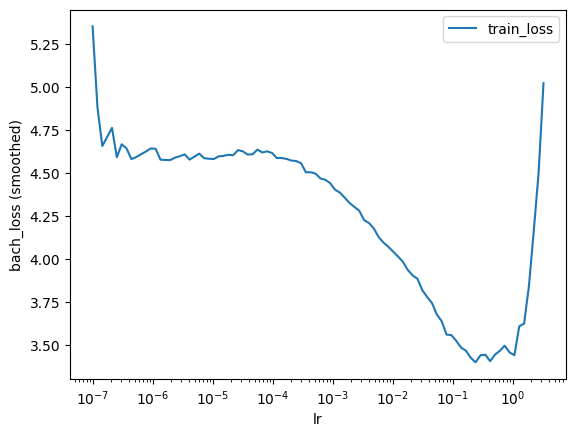

In [18]:
batch_size = batch_size
lrfinder = model.lr_finder(input=train_X,
                           target=(train_durations, train_events),
                           batch_size=batch_size,
                           tolerance=20)

_ = lrfinder.plot()

In [19]:
train_durations.shape

torch.Size([331])

In [20]:
model.optimizer.set_lr(lr)


In [21]:
epochs = 500
callbacks = [tt.torchtuples.callbacks.EarlyStopping(patience=35)]
verbose = True

### Training of the DeepSurv

In [22]:
%%time

set_seed(42)
log = model.fit(input=train_X, target=(train_durations, train_events), epochs=epochs, callbacks=callbacks, verbose=verbose, 
                val_data=(val_X,( val_durations, val_events)), val_batch_size=batch_size)

0:	[0s / 0s],		train_loss: 4.8430,	val_loss: 4.1091
1:	[0s / 0s],		train_loss: 4.3911,	val_loss: 3.9849
2:	[0s / 0s],		train_loss: 4.1931,	val_loss: 3.8693
3:	[0s / 0s],		train_loss: 3.5635,	val_loss: 3.7804
4:	[0s / 0s],		train_loss: 3.6074,	val_loss: 3.7140
5:	[0s / 0s],		train_loss: 3.6358,	val_loss: 3.6698
6:	[0s / 0s],		train_loss: 3.4956,	val_loss: 3.6360
7:	[0s / 0s],		train_loss: 3.5381,	val_loss: 3.6366
8:	[0s / 0s],		train_loss: 3.2436,	val_loss: 3.6330
9:	[0s / 0s],		train_loss: 3.1583,	val_loss: 3.6335
10:	[0s / 0s],		train_loss: 3.3710,	val_loss: 3.6391
11:	[0s / 0s],		train_loss: 3.1653,	val_loss: 3.6364
12:	[0s / 0s],		train_loss: 2.9407,	val_loss: 3.6329
13:	[0s / 0s],		train_loss: 3.0591,	val_loss: 3.6258
14:	[0s / 0s],		train_loss: 2.9319,	val_loss: 3.6048
15:	[0s / 0s],		train_loss: 2.9910,	val_loss: 3.5917
16:	[0s / 0s],		train_loss: 2.7108,	val_loss: 3.5853
17:	[0s / 0s],		train_loss: 2.9043,	val_loss: 3.5885
18:	[0s / 0s],		train_loss: 2.6881,	val_loss: 3.5753
19:

torch.Size([84, 1000])

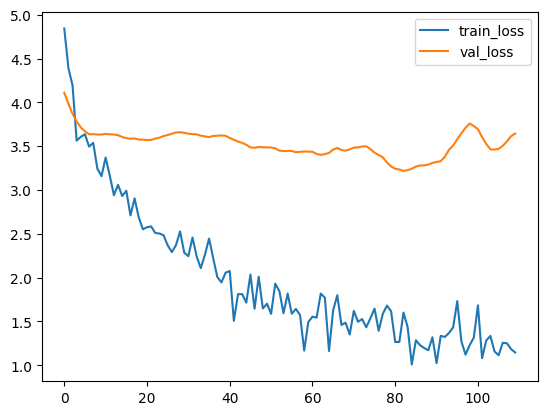

In [23]:
_ = log.plot()
val_X.shape

In [24]:
model.save_model_weights("Deepsurv_weights.pt")

#### K-M for the Training dataset

In [25]:
risk_nn_train = model.net(train_X).flatten()

list_risk_train = []
for i in risk_nn_train:
    list_risk_train.append(i.item())
    


For this group the risk High

For the time 0 the risk group is 158
For the time 12 the risk group is 121
For the time 24 the risk group is 40
For the time 36 the risk group is 16
For the time 48 the risk group is 7
For the time 60 the risk group is 0

For this group the risk Low

For the time 0 the risk group is 166
For the time 12 the risk group is 162
For the time 24 the risk group is 131
For the time 36 the risk group is 110
For the time 48 the risk group is 88
For the time 60 the risk group is 0


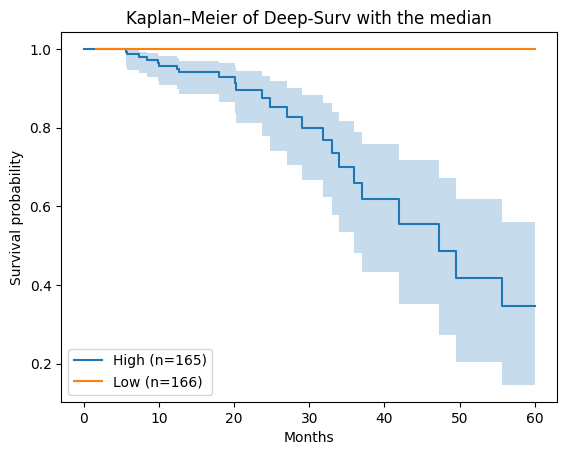

Log-rank: chi2=72.245, p=1.901e-17


(72.24492677583754, 1.900787254056425e-17)

In [29]:
k_m_cox(list_risk_train, train_durations, train_events, "Deep-Surv")

#### Log Likehood (The Loss) for the DeepSurv

In [30]:
model.partial_log_likelihood(*(val_X, (val_durations, val_events))).mean()


-3.2178428

In [31]:
_ = model.compute_baseline_hazards()

In [32]:
surv = model.predict_surv_df(input=test_X)

In [33]:
chf = model.predict_cumulative_hazards(test_X)
chf.shape
#275 → número de puntos de tiempo
#52 -> pacientes 

(220, 104)

#### K-M for the Test dataset DeepSurv

In [34]:
model.net.eval()
with torch.no_grad():
    risk_nn_test = model.net(torch.as_tensor(test_X, dtype=torch.float32)).flatten()

list_risk_test = []
for i in risk_nn_test:
    list_risk_test.append(i.item())



For this group the risk High

For the time 0 the risk group is 51
For the time 12 the risk group is 40
For the time 24 the risk group is 21
For the time 36 the risk group is 14
For the time 48 the risk group is 10
For the time 60 the risk group is 0

For this group the risk Low

For the time 0 the risk group is 52
For the time 12 the risk group is 43
For the time 24 the risk group is 30
For the time 36 the risk group is 20
For the time 48 the risk group is 15
For the time 60 the risk group is 0


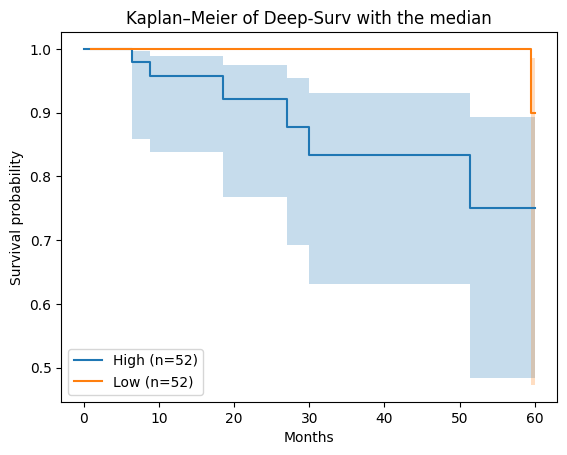

Log-rank: chi2=4.681, p=0.0305


In [36]:
chisq, p_value = k_m_cox(list_risk_test, test_durations, test_events, "Deep-Surv")

Prediction of survival of the Patients

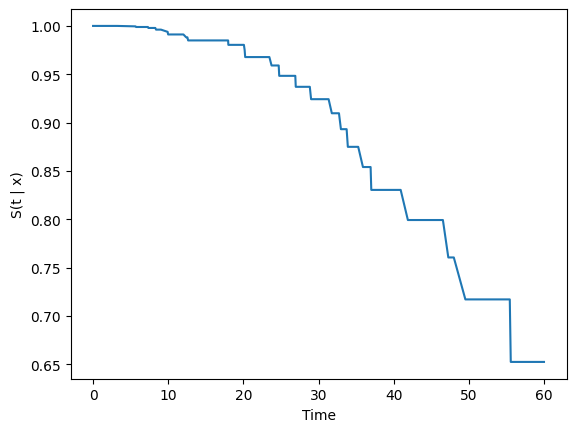

In [37]:
surv.mean(axis=1).plot()
plt.ylabel('S(t | x)')
plt.legend().set_visible(False)
_ = plt.xlabel("Time")

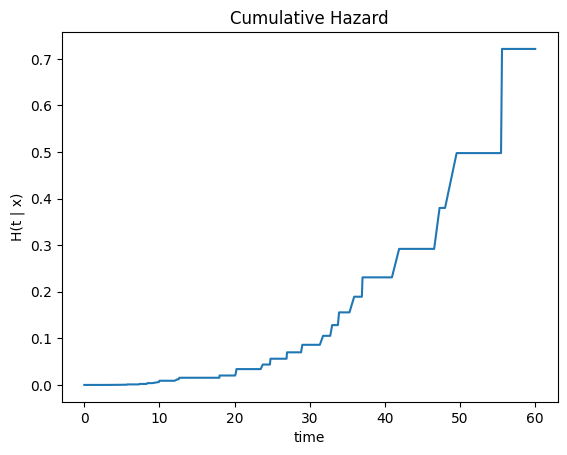

In [38]:
cum_haz = model.predict_cumulative_hazards(test_X)
cuz_model_mean = cum_haz.mean(axis=1)
cuz_model_mean.plot()
plt.xlabel("time")
plt.title("Cumulative Hazard")
plt.ylabel("H(t | x)")
plt.legend().set_visible(False)

In [39]:
test_X = np.array(test_X).astype('float32')
test_durations = np.array(test_durations).flatten()
test_events = np.array(test_events).astype(bool).flatten()

print(f"test_X shape: {test_X.shape}")
print(f"test_durations shape: {test_durations.shape}")
print(f"test_events shape: {test_events.shape}")

test_X shape: (104, 1000)
test_durations shape: (104,)
test_events shape: (104,)


In [40]:
set_seed(42)
ev = EvalSurv(surv=surv,
              durations=test_durations,
              events=test_events,
              censor_surv="km")


Concordance of the Model

In [41]:

print(f"Concordance of the model {ev.concordance_td()}")

Concordance of the model 0.8031914893617021


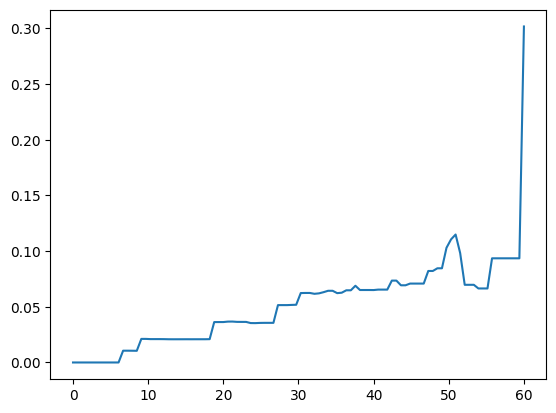

In [42]:
time_grid = np.linspace(test_durations.min(), test_durations.max(), 100)
_ = ev.brier_score(time_grid).plot()

In [43]:
ev.integrated_brier_score(time_grid=time_grid)

0.04994325545016669

In [44]:
ev.integrated_nbll(time_grid)
ci_test_deepsurv = ev.concordance_td()
ibs_deepsurv     = ev.integrated_brier_score(time_grid)

### Cox-Nnet

#### Grid Search for the Cox-Nnet

In [40]:
param_grid_cn = {
      "num_nodes":    [[32], [64], [128], [256]],
         "dropout":      [0],
      "batch_norm":   [True, False],
      "lr":           [1e-3, 5e-4, 1e-4],
      "weight_decay": [1e-4, 1e-3, 1e-2],
      "batch_size":   [64, 128, 256],
  }
grid_cn = list(product(
    param_grid_cn["num_nodes"],
    param_grid_cn["dropout"],
    param_grid_cn["batch_norm"],
    param_grid_cn["lr"],
    param_grid_cn["weight_decay"],
    param_grid_cn["batch_size"],
))

best_score_cn  = -1
best_params_cn = None
grid_results_cn = []
for num_nodes, dp, bn, lr, wd, batch_size in grid_cn:
    try:
        set_seed(42)
        net_cn = tt.torchtuples.practical.MLPVanilla(
            in_features  = in_features,
            num_nodes    = num_nodes,       # lista de 1 elemento
            out_features = 1,
            dropout      = dp,
            output_bias  = False,
            batch_norm   = bn,
        )
        model_cn_gs = CoxPH(net_cn, tt.torchtuples.optim.Adam(lr=lr, weight_decay=wd))

        callbacks = [tt.torchtuples.callbacks.EarlyStopping(patience=20)]
        model_cn_gs.fit(
            input      = train_X,
            target     = (train_durations, train_events),
            batch_size = batch_size,
            epochs     = 100,
            callbacks  = callbacks,
            verbose    = False,
            val_data   = (val_X, (val_durations, val_events)),
            val_batch_size = batch_size,
        )

        model_cn_gs.compute_baseline_hazards()
        surv_val_cn = model_cn_gs.predict_surv_df(val_X)
        ev_cn_gs    = EvalSurv(surv_val_cn, val_durations, val_events, censor_surv='km')
        c_index_cn  = ev_cn_gs.concordance_td()

        grid_results_cn.append({
            'num_nodes': num_nodes, 'dropout': dp, 'batch_norm': bn,
            'lr': lr, 'weight_decay': wd, 'batch_size': batch_size,
            'c_index': c_index_cn
        })

        if c_index_cn > best_score_cn:
            best_score_cn  = c_index_cn
            best_params_cn = {
                'num_nodes': num_nodes, 'dropout': dp, 'batch_norm': bn,
                'lr': lr, 'weight_decay': wd, 'batch_size': batch_size
            }
    except Exception as e:
        continue

print(f"Mejor C-index en validación (Cox-nnet): {best_score_cn:.4f}")
print(f"Mejores parámetros: {best_params_cn}")

Mejor C-index en validación (Cox-nnet): 0.7735
Mejores parámetros: {'num_nodes': [64], 'dropout': 0, 'batch_norm': True, 'lr': 0.001, 'weight_decay': 0.001, 'batch_size': 128}


#### The training of the Cox-Nnet

In [48]:
set_seed(42)
net_cn = tt.torchtuples.practical.MLPVanilla(
    in_features=in_features, 
    num_nodes=[64],
    out_features=1, 
    batch_norm=True,
    dropout=0,
    output_bias=False,
)
model_cn = CoxPH(net_cn, tt.torchtuples.optim.Adam(
    lr=0.001, weight_decay=0.001,
))
model_cn.fit(
    input=train_X, target=(train_durations, train_events),
    batch_size=128, epochs=200, verbose=True,
    callbacks=[tt.torchtuples.callbacks.EarlyStopping(patience=30)],
    val_data=(val_X, (val_durations, val_events)),
)

model_cn.compute_baseline_hazards()
surv_cn = model_cn.predict_surv_df(test_X)
ev_cn   = EvalSurv(surv_cn, test_durations, test_events, censor_surv='km')

ci_test_coxnnet = ev_cn.concordance_td()


0:	[0s / 0s],		train_loss: 4.4035,	val_loss: 3.7584
1:	[0s / 0s],		train_loss: 3.1781,	val_loss: 3.6793
2:	[0s / 0s],		train_loss: 2.6711,	val_loss: 3.5431
3:	[0s / 0s],		train_loss: 2.1675,	val_loss: 3.4377
4:	[0s / 0s],		train_loss: 1.7951,	val_loss: 3.3770
5:	[0s / 0s],		train_loss: 1.5952,	val_loss: 3.3676
6:	[0s / 0s],		train_loss: 1.4621,	val_loss: 3.3562
7:	[0s / 0s],		train_loss: 1.3337,	val_loss: 3.3411
8:	[0s / 0s],		train_loss: 1.1322,	val_loss: 3.3525
9:	[0s / 0s],		train_loss: 1.0970,	val_loss: 3.3555
10:	[0s / 0s],		train_loss: 0.9443,	val_loss: 3.3267
11:	[0s / 0s],		train_loss: 0.8872,	val_loss: 3.2754
12:	[0s / 0s],		train_loss: 0.7911,	val_loss: 3.2429
13:	[0s / 0s],		train_loss: 0.6833,	val_loss: 3.2835
14:	[0s / 0s],		train_loss: 0.7284,	val_loss: 3.3298
15:	[0s / 0s],		train_loss: 0.6301,	val_loss: 3.3657
16:	[0s / 0s],		train_loss: 0.5636,	val_loss: 3.3797
17:	[0s / 0s],		train_loss: 0.5824,	val_loss: 3.3984
18:	[0s / 0s],		train_loss: 0.5182,	val_loss: 3.5196
19:

In [50]:
print(f"\nC-index test  DeepSurv : {ev.concordance_td():.4f}  capas: {[32, 16]}")
print(f"C-index test  Cox-nnet : {ci_test_coxnnet:.4f}  capas: {[64]}")


C-index test  DeepSurv : 0.8032  capas: [32, 16]
C-index test  Cox-nnet : 0.8750  capas: [64]



For this group the risk High

For the time 0 the risk group is 51
For the time 12 the risk group is 40
For the time 24 the risk group is 20
For the time 36 the risk group is 13
For the time 48 the risk group is 10
For the time 60 the risk group is 0

For this group the risk Low

For the time 0 the risk group is 52
For the time 12 the risk group is 43
For the time 24 the risk group is 31
For the time 36 the risk group is 21
For the time 48 the risk group is 15
For the time 60 the risk group is 0


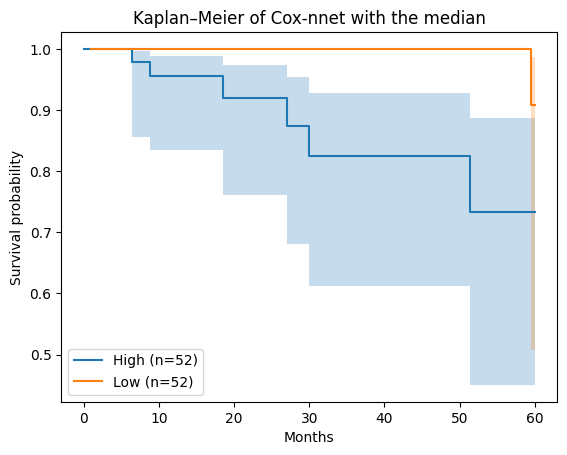

Log-rank: chi2=5.491, p=0.01911


In [52]:
model_cn.net.eval()
with torch.no_grad():
    risk_nn_test_cox_nnet = model_cn.net(
        torch.as_tensor(test_X, dtype=torch.float32)
    ).flatten()

list_risk_test_cox_nnet = risk_nn_test_cox_nnet.cpu().numpy().tolist()
chisq, p_value = k_m_cox(list_risk_test_cox_nnet, test_durations, test_events, "Cox-nnet")

In [53]:
train_X_np = train_X.cpu().numpy()
train_durations_np = train_durations.cpu().numpy()
train_events_np = train_events.cpu().numpy()
test_X_np = test_X

train_X_np.shape, train_durations_np.shape, train_events_np.shape

((331, 1000), (331,), (331,))

#### Saving of the Cox-Nnet

In [54]:
model_cn.save_model_weights("CoxNnet_weights.pt")